# Programmierpraktikum

### AGs Becker (Deep Decision Support Systems), Braun (Natural Language Processing), Ewerth (Multimodal Modelling and Machine Learning), Seifert (Explainable Artificial Intelligence)

Dieser Aufgabenblock soll Ihnen eine Einführung in die Programmiersprache Python und verschiedene KI-Anwendungen geben.

Alle Aufgaben sollen in den Code-Zellen in diesem iPython-Notebook gelöst werden. Stellen, an denen Code ergänzt werden soll, sind mit *`#ToDo`* Kommentaren gekennzeichnet.

---

## 01.09.2026 Teil 2: Clustering, Entscheidungsbäume, Computer Vision + Foundation Models
---
Die folgenden Aufgaben geschäftigen sich mit verschiedenen Methoden aus den Forschungsfeldern des Machine Learning und führen in die Bibliotheken scikit learn sowie tensorflow/keras ein. Hier sollen Sie sich anhand konkreter Anwendungen mit der Datenvorbereitung sowie dem Training einfacher KI-Modelle beschäftigen.

### Google Colab
*Hinweis*: Sollten die lokalen Rechenressourcen an Ihrem Rechner nicht ausreichen oder die durchzuführenden Modelltrainings sehr lange dauern, können Sie auch Google Colab (https://colab.research.google.com) verwenden, um den Code auszuführen. In diesem Fall sollten Sie Ihr Google Drive mit dem nachfolgenden Befehl mounten und alle während der Lösung der Aufgaben erzeugten Dateien dort speichern, da sie sonst beim Beenden des Notebooks verloren gehen.

In [7]:
# Ausführen, wenn dieses Notebook in Google Drive bearbeitet wird
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

Nach der Ausführung wird ein Link angezeigt, über den Sie ein Token abrufen können. Nachdem Sie dieses eingegeben haben, können Sie über den Pfad `'/content/drive/MyDrive/...'` auf die Ordnerstruktur Ihres Google Drives zugreifen.

### Shared Imports

In [ ]:
from typing import List, Dict, Tuple, Any, Union, Optional

## Aufgabe 2.1: KMeans Clustering ( *2 + 2 + 1 = 5 Punkte* )

Diese Aufgabe konzentriert sich auf Clustering, also die Gruppierung von Daten anhand von Ähnlichkeiten (in diesem Fall der räumlichen Nähe). 

Der [KMeans Clusteringalgorithmus](https://de.wikipedia.org/wiki/K-Means-Algorithmus) optimiert dabei die Position einer zuvor gewählten Anzahl von $k$ Clusterzentren und ordnet die Datenpunkte dem jeweils nächstgelegenen Zentrum zu.

<table>
<tr>
    <td> <img src="https://media.geeksforgeeks.org/wp-content/uploads/20251113113327508549/Poor-Clustering.jpg" alt="Bild eines Clusterings mit schlecht gewählten Clusterzentren."> </td> 
    <td> <img src="https://media.geeksforgeeks.org/wp-content/uploads/20251113113327169016/Screenshot-2025-11-13-113339.jpg" alt="Bild eines Clusterings mit ideal gewählten Clusterzentren."> </td>
</tr>
</table>

Die Bibliothek [Scikit Learn](https://scikit-learn.org) stellt simple und effiziente Tools zur Datenanalyse bereit. Sie ermöglicht unter anderem das Training von Machine Learning Algorithmen zur Klassifikation, Regression oder Clustering von Daten.

In [ ]:
!pip install scikit-learn

In [ ]:
import pandas as pd
# load dataframe
df = pd.read_csv("clustering.csv")

### Aufgabe 2.1 a) 
Implementieren Sie die Funktion `plot_predictions`, die Punkte aus dem gegebenen DataFrame und ihre Zuordnung zu Clustern als [Scatterplot](https://seaborn.pydata.org/generated/seaborn.scatterplot.html) visualisiert. Verwenden Sie für die farbliche Clusterzuornung die `'tab10'` Farbpalette. Außerdem soll die Methode die Position der Cluster-Zentren gut sichtbar einzeichnen (z.B. mit einem größeren Kreis, der die Cluster-Nummer enthält). Dafür soll keine Legende angezeigt werden.

*Hinweis*: Zum Testen wurde ein Default-Wert für die Cluster-Zuordnung in das DataFrame eingefügt und eine Test-Clusterposition angegeben.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd  

def plot_predictions(df_pred: pd.DataFrame, cluster_centers: np.array) -> None:  # 2 Punkte
  
    sns.scatterplot(
        data=df_pred, 
        x='x', 
        y='y', 
        hue='cluster', 
        palette='tab10', 
        legend=False
    )
    
   
    for idx, (cx, cy) in enumerate(cluster_centers):
        plt.scatter(cx, cy, s=250, color='black', alpha=0.75, edgecolors='black', zorder=5)
        plt.text(cx, cy, str(idx), color='white', fontsize=10, ha='center', va='center', weight='bold', zorder=6)


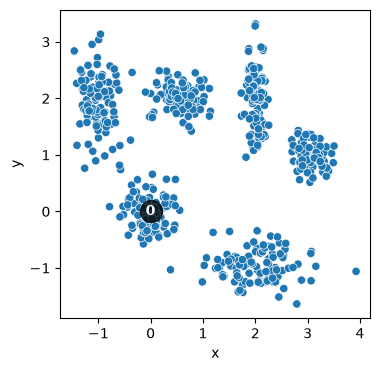

In [ ]:
# dummy values for testing
df_pred = df.copy()
df_pred['cluster'] = 0
cluster_centers = np.array([[0,0]])

plt.figure(figsize=(4,4))
plot_predictions(df_pred, cluster_centers)
plt.show()

### Aufgabe 2.1 b) 
Implementieren Sie nun die Funktion `kmeans_prediction`, die den [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) Clustering Algorithmus auf das DataFrame anwendet und die Clusterzuordnung in die Spalte `'cluster'` einträgt. Außerdem sollen die ermittelten Clusterzentren zurückgegeben werden. Visualisieren Sie die ermittelte Clusterzuordnung für $k=2$ Cluster.

*Hinweis*: Setzen Sie den Parameter `n_init` des `KMeans`-Objekts auf 5, um die Chance einer schlecht gewählten Initialisierung der Clusterzentren zu verringern.

In [ ]:
import pandas as pd
import numpy as np
from typing import Tuple
from sklearn.cluster import KMeans


def kmeans_prediction(df: pd.DataFrame, k: int) -> Tuple[pd.DataFrame, np.array]:  # 2 Punkte
    df_pred = df.copy()

    # ToDo
    kmeans = KMeans(n_clusters=k, n_init=5, random_state=42)
    df_pred['cluster'] = kmeans.fit_predict(df_pred[['x', 'y']])
    cluster_centers = kmeans.cluster_centers_
    return df_pred, cluster_centers

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))
df_pred, clusters = kmeans_prediction(df, k=2)
plot_predictions(df_pred, clusters)
plt.show()


NameError: name 'plt' is not defined

### Aufgabe 2.1 c) 
Implementieren Sie die Funktion `kmeans_multiple`, die den KMeans Algorithmus nacheinander für verschiedene Cluster-Zahlen $k$ ausführt und die Ergebnisse in einer gemeinsamen Figure visualisiert. Als Titel der jeweiligen Subplots soll die Anzahl der Cluster angegeben werden.

Plotten Sie die Clusterings für $k \in \{4, ..., 8\} $. Welche Anzahl an Clustern ist für die vorliegenden Daten am besten geeignet?

In [ ]:
def kmeans_multiple(df: pd.DataFrame, ks: List[int]) -> None:  # 1 Punkt
    num_subplots = len(ks)
    fig, axs = plt.subplots(1,  num_subplots, figsize=(3*num_subplots, 4), sharey=True)

    for k_index, k_value in enumerate(ks):
        plt.sca(axs[k_index]) # set current subplot

        # ToDo
        pass

    plt.tight_layout()
    plt.show()

kmeans_multiple(df, ks=range(4, 9))

---
## Aufgabe 2.2: Entscheidungsbäume ( *3 + 4 + 1 + 4 = 12 Punkte* )

In dieser Aufgabe wollen wir [Entscheidungsbäume](https://de.wikipedia.org/wiki/Entscheidungsbaum) kennenlernen, die zur *überwachten* Klassifizierung von Daten genutzt werden.

Überwachtes Lernen heißt, dass im Gegensatz zum Clustern in Aufgabe 2.1 hier Datensätze verwendet werden, bei denen die Klassenzugehörigkeit der einzelnen Datenpunkte bekannt ist. Das Modell soll so an den Datensatz angepasst werden, dass es neuen Datenpunkten eine plausible Klasse zuweist. Diese Plausibilität kann über diverse Metriken quantifiziert werden (siehe Aufgabe 2.3). In dieser Aufgabe sollen Sie sich zunächst mit den Entscheidungsbäumen an sich beschäftigen: verstehen, wie sie angepasst werden, ihre Entscheidungsgrenzen visualisieren und echte Erkenntnisse über die Daten aus ihnen extrahieren.

Wir nutzen dafür den [Breast Cancer Wisconsin](https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-wisconsin-diagnostic-dataset) Datensatz, der direkt in Scikit Learn enthalten ist. Für 569 Patientinnen wurde jeweils ein mikroskopisches Bild einer Gewebeprobe vermessen: Größe, Form und Randbeschaffenheit der abgebildeten Zellkerne. Zehn solcher Grundgrößen wurden je Bild dreifach ausgewertet: als Mittelwert (`mean ...`), als Streuung (`... error`) und als Mittel der drei größten Werte (`worst ...`), woraus sich die 30 Merkmale ergeben. Die Spalte `diagnosis` gibt an, ob der Befund gutartig (`benign`) oder bösartig (`malignant`) war.

In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

bc = load_breast_cancer(as_frame=True)
df_bc = bc.data.copy()
df_bc.insert(0, 'diagnosis', bc.target_names[bc.target])

print(f"{df_bc.shape[0]} Patientinnen, {df_bc.shape[1] - 1} Merkmale")
print(df_bc['diagnosis'].value_counts().to_string())
df_bc.iloc[:5, :5]

### Aufgabe 2.2 a)

Ein Entscheidungsbaum wird aufgebaut, indem an jedem Knoten die Datenmenge in zwei Teile zerlegt wird. Welche Zerlegung die beste ist, misst die [**Gini-Impurity**](https://sebastiansauer.github.io/datascience1/entscheidungsb%C3%A4ume.html#gini-als-optimierungskriterium): Sie ist 0, wenn alle Datenpunkte in einem Knoten zur selben Klasse gehören, und maximal, wenn die Klassen gleich verteilt sind.

$$G(S) = 1 - \sum_k p_k^2$$

Dabei ist $p_k$ der Anteil der Klasse $k$ im Knoten. Ein Split zerlegt $S$ in $S_1$ und $S_2$; die Unreinheit danach ist der gewichtete Mittelwert beider Teile:

$$G_{\text{nach}} = \frac{|S_1|}{|S|} G(S_1) + \frac{|S_2|}{|S|} G(S_2)$$

Der Baum wählt an jedem Knoten den Split mit der größten Reduktion $\Delta G = G(S) - G_{\text{nach}}$.

Implementieren Sie die beiden Formeln in den Funktionen `gini` und `weighted_gini`. Vervollständigen Sie anschließend `best_split`: Die Funktion probiert für ein einzelnes Merkmal alle sinnvollen Schwellwerte durch und gibt den besten zurück. Die Kandidaten und die Schleife darüber sind bereits vorgegeben, ergänzen Sie darin, wie die Punkte am Schwellwert aufgeteilt werden und wie groß die Reduktion dabei ausfällt.

*Hinweis*: Die Klassenanteile $p_k$ erhalten Sie zum Beispiel mit `np.unique(y, return_counts=True)`.

*Hinweis*: `x <= threshold` liefert ein Boolean-Array, mit dem Sie `y` wie in Aufgabe 1.4 c) indizieren können; `~maske` wählt die übrigen Punkte.

In [ ]:
import numpy as np


def gini(y: np.ndarray) -> float:  # 1 Punkt
    # ToDo
    return -1


def weighted_gini(y_left: np.ndarray, y_right: np.ndarray) -> float:  # 1 Punkt
    # ToDo
    return -1


def best_split(x: np.ndarray, y: np.ndarray) -> Tuple[float, float]:  # 1 Punkt
    """Gibt (Schwellwert, Gini-Reduktion) für den besten Split zurück."""
    # als Kandidaten nehmen wir die Mittelpunkte zwischen je zwei
    # aufeinanderfolgenden vorkommenden Werten
    values = np.unique(x)
    thresholds = (values[:-1] + values[1:]) / 2
    gini_before = gini(y)

    best_threshold, best_reduction = -1.0, -1.0

    for threshold in thresholds:
        # ToDo: Punkte mit einer Boolean-Maske am Schwellwert in zwei Teile trennen
        # und die Gini-Reduktion dieses Splits bestimmen
        # besten Kandidaten merken
        pass

    return best_threshold, best_reduction


assert gini(np.array(['a', 'a', 'a'])) == 0.0                              # reiner Knoten
assert gini(np.array(['a', 'b'])) == 0.5                                   # maximal gemischt
assert np.isclose(gini(np.array(['a', 'a', 'b', 'b', 'b', 'b'])), 4 / 9)
assert weighted_gini(np.array(['a', 'a']), np.array(['b', 'b'])) == 0.0    # perfekter Split
assert best_split(np.array([1.0, 2.0, 3.0, 4.0]), np.array(['a', 'a', 'b', 'b'])) == (2.5, 0.5)

print("Alle Tests bestanden.")

Die Funktion `best_split` löst damit das Teilproblem, das an jedem Knoten eines Entscheidungsbaums zu lösen ist, allerdings nur für ein einzelnes Merkmal. Ein Baum prüft an jedem Knoten alle Merkmale und übernimmt davon den Split mit der größten Gini-Reduktion. Die Zelle unten führt diese Auswahl von Hand aus: Sie ruft `best_split` für `mean radius` und `mean concavity` einzeln auf und vergleicht das Ergebnis mit dem Split, den [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) aus Scikit Learn an der Wurzel wählt.

Wählt Ihre Implementierung dasselbe Merkmal und denselben Schwellwert, rechnet sie genauso wie die Bibliothek. In den folgenden Aufgabenteilen verwenden wir dann `DecisionTreeClassifier` selbst: Er wiederholt genau diesen Schritt rekursiv auf beiden Hälften, bis der ganze Baum aufgebaut wurde.

In [ ]:
from sklearn.tree import DecisionTreeClassifier


FEATURES = ['mean radius', 'mean concavity']

X_2d = df_bc[FEATURES].values
y_bc = df_bc['diagnosis'].values

for i, feature in enumerate(FEATURES):
    threshold, reduction = best_split(X_2d[:, i], y_bc)
    print(f"{feature:16s} bester Schwellwert {threshold:6.3f}  Gini-Reduktion {reduction:.4f}")

# Zum Vergleich: der erste Split, den Scikit Learn selbst wählt
root = DecisionTreeClassifier(max_depth=1, random_state=42).fit(X_2d, y_bc)
print(f"\nsklearn wählt: {FEATURES[root.tree_.feature[0]]} <= {root.tree_.threshold[0]:.3f}")

### Aufgabe 2.2 b)

Mit genau zwei Merkmalen ist der Merkmalsraum eine Ebene. Wir können den Baum deshalb in zwei Sichten darstellen: als Baumdiagramm und als Aufteilung dieser Ebene, in der jeder Split zu einer achsenparallelen Linie und jedes Blatt zu einem rechteckigen Bereich wird. Die Zelle unten zeichnet beide nebeneinander.

Implementieren Sie die Funktion `fit_tree`, die einen [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) mit den übergebenen Einschränkungen an die Daten anpasst und zurückgibt, sowie `draw_splits`, die die gelernten Schwellwerte als Linien in den Plot einzeichnet.

*Hinweis*: `fit_tree` bekommt die Einschränkungen des Baums als Parameter, damit wir dieselbe Funktion in Aufgabenteil c) mit anderen Werten wiederverwenden können; ein nicht gesetzter Parameter (`None`) bedeutet „keine Einschränkung“. Hier rufen wir sie mit `max_leaf_nodes=3` auf, damit der Baum genau drei Blätter bildet.

*Hinweis*: Senkrechte Linien zeichnen Sie mit [`plt.vlines`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.vlines.html), waagerechte analog mit `plt.hlines`.

*Hinweis*: `clf.tree_.threshold` enthält die gelernten Schwellwerte, indiziert nach Knoten: Index `0` ist die Wurzel, Index `1` ihr linkes Kind. Überlegen Sie außerdem, über welchen Bereich die zweite Linie gezeichnet werden darf: ein Kindknoten ist nur für den Teil der Ebene zuständig, den sein Elternknoten ihm übergibt.

*Hinweis*: `plot_decision_regions` färbt die Ebene bereits danach ein, welche Klasse der Baum wo vorhersagt. Ihre Linien zeigen hingegen, wie der Baum die Ebene dafür zerlegt hat. Ein Teil einer Ihrer Linien verläuft zwischen zwei gleichfarbigen Bereichen: dort trennt der Baum zwei Blätter, die dieselbe Klasse vorhersagen.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text


def plot_decision_regions(clf: DecisionTreeClassifier, X: np.ndarray, y: np.ndarray,
                          legend: bool = True) -> None:
    """Färbt die Ebene nach der Vorhersage des Baums und zeichnet die Datenpunkte darüber.
    Diese Funktion ist bereits vollständig implementiert."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.02, X[:, 1].max() + 0.02
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

    classes = list(clf.classes_)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = np.vectorize(classes.index)(Z).reshape(xx.shape)
    plt.contourf(xx, yy, Z, levels=np.arange(len(classes) + 1) - 0.5,
                 cmap=ListedColormap(sns.color_palette('tab10', len(classes))), alpha=0.18)

    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, hue_order=classes, palette='tab10',
                    s=16, alpha=0.85, linewidth=0.2, edgecolor='white', legend=legend)

    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xlabel(FEATURES[0])
    plt.ylabel(FEATURES[1])

In [ ]:
def fit_tree(X: np.ndarray, y: np.ndarray, max_depth: Optional[int] = None,
             max_leaf_nodes: Optional[int] = None) -> DecisionTreeClassifier:  # 2 Punkte
    """Passt einen Entscheidungsbaum mit den uebergebenen Einschraenkungen an."""
    # ToDo
    return DecisionTreeClassifier()


def draw_splits(clf: DecisionTreeClassifier) -> None:  # 2 Punkte
    # ToDo
    pass

In [ ]:
clf_2d = fit_tree(X_2d, y_bc, max_leaf_nodes=3)

plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
plot_decision_regions(clf_2d, X_2d, y_bc)
draw_splits(clf_2d)
plt.title("Entscheidungsgrenzen")

plt.subplot(1, 2, 2)
plot_tree(clf_2d, feature_names=FEATURES, class_names=clf_2d.classes_,
          filled=True, impurity=False)
plt.title("Derselbe Baum als Baumdiagramm")

plt.tight_layout()
plt.show()

### Aufgabe 2.2 c)

Die Tiefe eines Entscheidungsbaumes bestimmt, wie komplex seine Entscheidungsgrenzen werden können. Um dafür ein Gefühl zu bekommen, visualisieren wir die Entscheidungsgrenzen von Bäumen unterschiedlicher Tiefe nebeneinander – also ein "Hyperparameter-Sweep" analog zu Aufgabe 2.1 c).

Implementieren Sie die Funktion `plot_boundaries_multiple`, die für jede Tiefe aus `depths` einen Baum anpasst und die Entscheidungsgrenzen in einer gemeinsamen Figure visualisiert. Geben Sie im Titel der Subplots jeweils die Tiefe und die Anzahl der Blätter an. Führen Sie die Funktion für die Tiefen $1, 2, 3, 5$ sowie ohne Begrenzung (`None`) aus. Was fällt Ihnen an den Entscheidungsgrenzen auf, je tiefer der Baum wird?

*Hinweis*: Verwenden Sie `fit_tree` und `plot_decision_regions` aus Aufgabenteil b) wieder. Die Anzahl der Blätter erhalten Sie mit `clf.get_n_leaves()`.

In [ ]:
def plot_boundaries_multiple(X: np.ndarray, y: np.ndarray, depths: List[Optional[int]]) -> None:  # 1 Punkt
    num_subplots = len(depths)
    fig, axs = plt.subplots(1, num_subplots, figsize=(4 * num_subplots, 4), sharey=True)

    for depth_index, depth_value in enumerate(depths):
        plt.sca(axs[depth_index])  # set current subplot

        # ToDo
        pass

    plt.tight_layout()
    plt.show()


plot_boundaries_multiple(X_2d, y_bc, depths=[1, 2, 3, 5, None])

Antwort: 

### Aufgabe 2.2 d)

Bisher haben wir dem Baum genau zwei Merkmale vorgegeben, die wir selbst ausgewählt haben. Jetzt sollen alle 30 Merkmale betrachtet werden und mit dem Verfahren aus Aufgabenteil a) automatisch die besten Splits ausgewählt werden.

Wie gut ein Modell dabei klassifiziert, misst man mit Metriken wie der Accuracy (dazu mehr in Aufgabe 2.3). Hier interessiert uns etwas anderes: Wir nehmen den angepassten Baum als gegeben und fragen, was er uns über die Daten verrät.

Implementieren Sie die Funktionen `prepare_full_data`, `used_features` und `plot_importances` und schauen Sie sich an, welche Merkmale der Baum tatsächlich verwendet.

*Hinweis*: Nutzen Sie [`sns.barplot`](https://seaborn.pydata.org/generated/seaborn.barplot.html) zum Plotten.

*Hinweis*: `max_depth=3` ist hier bewusst klein gewählt, damit der Baum als Ganzes lesbar bleibt.

In [ ]:
def prepare_full_data(df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, List[str]]:  # 1.5 Punkte
    """Zerlegt `df` in Merkmalsmatrix, Klassenvektor und die Namen der Merkmalsspalten."""
    # ToDo
    return np.zeros([1,30]), np.zeros([1,30]), [""]*30


def used_features(clf: DecisionTreeClassifier, feature_names: List[str]) -> pd.Series:  # 1.5 Punkte
    """Gibt alle Merkmale mit einer Importance größer 0 zurück, absteigend sortiert."""
    # ToDo
    return pd.Series()


def plot_importances(importances: pd.Series) -> None:  # 1 Punkt
    # ToDo
    pass

In [ ]:
X_full, y_full, feature_names = prepare_full_data(df_bc)

clf_full = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_full.fit(X_full, y_full)

used = used_features(clf_full, feature_names)
print(f"Der Baum benutzt {len(used)} von {len(feature_names)} Merkmalen.")

plt.figure(figsize=(6, 3.5))
plot_importances(used)
plt.tight_layout()
plt.show()

Antwort: 

In [ ]:
# Sieben Merkmale, acht Blätter: Die induzierten Regeln des komplett trainierten
# Klassifikators passen auf eine Bildschirmseite.
print(export_text(clf_full, feature_names=feature_names))

# Hier geben wir die Importance der beiden Merkmale aus b) und c) aus, sowie ihre
# Korrelation mit den Merkmalen, die der Baum stattdessen gewählt hat.
importances = pd.Series(clf_full.feature_importances_, index=feature_names)
print("Importance der Merkmale aus b) und c):")
print(importances[FEATURES].to_string())

print("\nKorrelation mit den benutzten Merkmalen:")
print(df_bc[FEATURES + list(used.index)].corr().loc[used.index, FEATURES].round(3).to_string())

Antwort: 

---
## Aufgabe 2.3: Computer Vision: MNIST ( *2 + 2 + 3 + 4 + 1 + 2 + 2 + 1 + 5 + 3 = 25 Punkte* )

Diese Aufgabe beschäftigt sich mit dem Training einfacher neuronaler Netzwerke zur Bilderkennung. 

Neuronale Netzwerke bestehen aus in Schichten hintereinander angeordneten [künstlichen Neuronen](https://de.wikipedia.org/wiki/K%C3%BCnstliches_Neuron). Ein solches Neuron erhält mehrere Eingaben und erzeugt daraus einen einzelne Ausgabe.
Den Verbindungen zwischen den Neuronen sind dabei Gewichte zugeordnet. Jedes Neuron berechnet eine gewichtete Summe seiner Eingaben, addiert einen Bias und wendet eine nicht-lineare Aktivierungsfunktion an, um die Ausgabe zu erhalten. 

In einem aus mehreren Schichten (Layern) bestehenden Neuronalen Netzwerk wandern Signale von der ersten Schicht (Eingabeschicht, Input Layer) zur letzten Schicht (Ausgabeschicht, Output Layer) und durchlaufen dabei mehrere Zwischenschichten (versteckte Schichten, Hidden Layers), wobei jede Schicht die Signale unterschiedlich transformieren kann. Ein Netz mit vielen verborgenen Schichten wird als tiefes neuronales Netz bezeichnet. Darauf bezieht sich der Begriff „Deep Learning“.
<!--![Aufbau eines künstlichen Neurons](https://upload.wikimedia.org/wikipedia/commons/thumb/9/96/NeuronModel_deutsch.svg/960px-NeuronModel_deutsch.svg.png?utm_source=de.wikipedia.org&utm_campaign=index&utm_content=thumbnail)-->
![Aufbau eines neuronalen Netzwerks mit drei inneren Schichten](https://upload.wikimedia.org/wikipedia/commons/thumb/1/15/Neural_Network.svg/960px-Neural_Network.svg.png?utm_source=en.wikipedia.org&utm_campaign=index&utm_content=thumbnail)

Um ein neuronales Netzwerk zur Bildklassifikation zu trainieren werden Trainingsdaten benötigt, in denen den Eingaben (Bildern) die gewünschten Ausgaben (Klassenlabels) zugeordnet sind. Während des Trainings werden die Eingaben in das Netzwerk eingespeist und die Vorhersage des Netzwerks mit dem gewünschten Zielwert anhand von einer Loss-Funktion verglichen. Die Gewichte und Bias-Werte werden dann anhand eines Optimierungsalgorithmus so angepasst, dass der Fehler zwischen Vorhersage und Zielwert kleiner wird. Dieser Prozess wird über mehrere Epochen wiederholt, um den Fehler immer weiter zu minimieren.

Nach dem Training ist das neuronale Netzwerk in der Lage Vorhersagen auch auf vorher nicht gesehenen Testdaten durchzuführen. Um zu bewerten wie gut die Vorhersagen des neuronalen Netzwerks sind, werden Metriken berechnet, die die Ähnlichkeit von Vorhersage und Zielwert messen. Die einfachste Metrik ist Accuracy, definiert als die Anzahl der korrekten Vorhersagen geteilt durch die Anzahl aller Vorhersagen.

In dieser Aufgabe verwenden wir [Tensorflow](https://www.tensorflow.org/) als Machine-Learning Backend und [Keras](https://keras.io/) als High-Level Framework zum Laden der Daten und Trainieren der neuronalen Netzwerke. In Keras werden keine einzelnen Neuronen definiert, sondern immer ganze Neuronenschichten (Layer). Im einfachsten Fall sind diese sequentiell nacheinander angeordnet. Neben vollständig verbundenen Schichten, die eine Verbindung zu allen Neuronen aus der vorherigen Schicht haben, werden wir auch weitere Schichten verwenden, die andere Funktionalitäten bereitstellen.

In [ ]:
# install required libraries
!pip install tensorflow

Als Anwendungsbeispiel dient in dieser Aufgabe der [MNIST](https://keras.io/api/datasets/mnist/) Datensatz, der Bilder handschriftlicher Ziffern (0-9) enthält. Diese sollen von einem neuronalen Netzwerk erkannt werden. 

![Beispielbilder aus dem MNIST-Datensatz](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png?utm_source=en.wikipedia.org&utm_campaign=imageinfo&utm_content=thumbnail_unscaled)

### Aufgabe 2.3 a) 
Schreiben Sie eine Funktion `load_mnist`, die den [MNIST](https://keras.io/api/datasets/mnist/) Datensatz über die Keras-Dataset-API läd und die Pixelwerte aller Bilder zwischen 0 und 1 normalisiert.

In [ ]:
import keras
import os
import warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore", category=UserWarning, module="keras")
import tensorflow as tf
tf.get_logger().setLevel("ERROR")

In [ ]:
def load_mnist() -> Tuple[Tuple[np.array, np.array], Tuple[np.array, np.array]]:  # 2 Punkte
    # ToDo    
    return (np.zeros(0), np.zeros(0)), (np.zeros(0), np.zeros(0))

(x_train, y_train), (x_test, y_test) = load_mnist()

assert x_train.shape == (60000, 28, 28)
assert x_train.min() == 0 and x_train.max() == 1
assert x_test.shape == (10000, 28, 28)
assert x_test.min() == 0 and x_test.max() == 1
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)
print("MNIST dataset successfully loaded and normalized.")

### Aufgabe 2.3 b) 
Machen Sie sich mit dem Datensatz vertraut und visualisieren Sie mithilfe der Funktion `visualize_dataset` 10 zufällige Bilder und deren Labels aus den Testdaten.

In [ ]:
import matplotlib.pyplot as plt

def visualize_dataset(x: np.array, y: np.array, n: int) -> None:   # 2 Punkte
    fig = plt.figure(figsize=(12,3))

    # ToDo 
    pass
    
    plt.tight_layout()
    plt.show()

visualize_dataset(x_test, y_test, 10)

### Aufgabe 2.3 c) 
Implementieren Sie eine Funktion `setup_dense_model`, die ein sequentielles neuronales Netzwerk (`keras.models.Sequential`) zur Klassifikation der MNIST-Bilder aufbaut.

* Dieses soll einen `Flatten`-Layer nach der Eingabeschicht verwenden, um die zweidimensionalen Bilder in einen eindimensionalen Vektor umzuwandeln, gefolgt von zwei vollständig verbundenen Schichten (`Dense`-Layer) mit absteigender Zahl an Neuronen (300, 100) und ReLU-Aktivierungsfunktion. Als Ausgabeschicht soll eine weitere vollständig verbundene Schicht dienen, die der Anzahl der Klassen entsprechend aus 10 Neuronen besteht und die Softmax-Aktivierungsfunktion verwendet.
Es soll also folgender Aufbau abgebildet werden:

| Layer        | Parameters     |                     |
|--------------|----------------|---------------------|
| Input        | shape: 28x28x1 |                     |
| Flatten      |                |                     |
|              |                |                     |
| Dense        | units: 300     | activation: relu    |
| Dense        | units: 100     | activation: relu    |
|              |                |                     |
| Dense        | units: output  | activation: softmax |


* Weisen Sie dem Modell den Namen `'dense_<timestamp>'` zu.
  
* Kompilieren Sie das Modell und geben Sie dabei `'adam'` als Optimierer, `'sparse_categorical_crossentropy'` als Loss-Funktion sowie `'accuracy'` als Metrik an.

* Rufen Sie die `summary()`-Funktion des Modells auf, um eine Übersicht über die Schichten des Modells sowie die Anzahl der Parameter (Gewichte) anzuzeigen.

In [ ]:
import datetime

def setup_dense_model(outputs: int = 10) -> keras.models.Model:   # 3 Punkte
    timestamp = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
    
    # ToDo

    # setup model
    model = keras.models.Sequential()
    
    # compile model
    
    return model

m_dense = setup_dense_model()

### Aufgabe 2.3 d) 
Führen Sie nun das Training Ihres Modells auf den MNIST-Trainingsdaten durch (`model.fit`). 
* Erstellen Sie mit der Funktion `setup_callbacks` die folgenden Callbacks, die während des Trainings automatisch aufgerufen werden sollen:
  * `Tensorboard`-Callback, um den Trainingsfortschritt im gegebenen Log-Verzeichnis zu loggen
  * `EarlyStopping`-Callback, damit das Training automatisch gestoppt wird, wenn es über fünf Epochen zu keiner Verbesserung mehr kommt. In diesem Fall sollen die Gewichte des besten Modells wiederhergestellt werden.
  * `ModelCheckpoint`-Callback mit dem Parameter `save_best_only=True`, um die erlernten Gewichte ihres Modells automatisch zu speichern. Als Speicherort soll ein Unterordner `model` im Log-Verzeichnis verwendet werden.
* Verwenden Sie dann die Funktion `train_model`, um das übergebene Modell mit den gegebenen Daten zu trainieren
  * Trainieren Sie das Modell für maximal 20 Epochen
  * Verwenden Sie den Parameter `validation_split=0.3`, um einen Teil der Trainingsdaten zur automatischen Validierung während des Trainings zu verwenden

In [ ]:
def setup_callbacks(model: keras.models.Model) -> List[keras.callbacks.Callback]:   # 2 Punkte
    log_dir = f"logs/{model.name}"

    # ToDo

    return [ ]

def train_model(model: keras.models.Model, x_train: np.array, y_train: np.array, epochs: int, validation_split: float = 0.3) -> None:   # 1 Punkt
    # ToDo
    pass

In [ ]:
train_model(m_dense, x_train, y_train, 20)  # 1 Punkt

### Aufgabe 2.3 e) 

Rufen Sie Tensorboard auf, um die Entwicklung von **Loss** und **Accuracy** im Verlauf des Trainings visualisieren zu lassen.
* Im Browser:
  * Starten von Tensorboard über die Kommandozeile: `tensorboard --logdir logs/`
  * Öffnen von http://localhost:6006/ im Webbrowser
* In Notebook-Zelle:
  * Laden von Tensorboard-Extension über Line-Magic: `%load_ext tensorboard`
  * Starten von Tensorboard in Notebook-Zelle über Line-Magic: `%tensorboard --logdir logs/`
 
Was fällt Ihnen auf?

In [ ]:
# 1 Punkt
# ToDo

Antwort: 

### Aufgabe 2.3 f) 

Implementieren Sie die Funktion `evaluate_model`, um Ihr trainiertes Netzwerk auf den MNIST-Testdaten auszuwerten. Geben Sie die erhaltene Accuracy an.

Implementieren Sie außerdem die Funktion `predict_model`, um mit Ihrem trainierten Netzwerk Vorhersagen auf den MNIST-Testdaten durchzuführen. Die Funktion soll dabei nicht die Klassenwahrscheinlichkeiten, sondern den Index des Labels mit der jeweils höchsten Wahrscheinlichkeit zurückliefern.

*Hinweis*: Um diese Indizes zu bestimmen können Sie die Numpy-Funktion `argmax` verwenden.

In [ ]:
def evaluate_model(model: keras.models.Model, x_test: np.array, y_test: np.array) -> float:  # 1 Punkt
    # ToDo
    return -1
    
print(f"Test Accuracy: {evaluate_model(m_dense, x_test, y_test):.2%}")


def predict_model(model: keras.models.Model, x_test: np.array) -> np.array:  # 1 Punkt
    # ToDo    
    return np.zeros(0)
    
preds_test = predict_model(m_dense, x_test)
print(f"Predictions were made for {len(x_test)} images.")

### Aufgabe 2.3 g)
Implementieren Sie die Funktion `plot_confusion_matrix`, um die Predictions in Form einer [Confusion-Matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) darzustellen, in der aufsummiert wird, wie häufig welche vorhergesagte Klasse welcher gewünschten Klasse zugeordnet wurde. Normalisieren Sie die Werte der Confusion-Matrix pro Groundtruth-Klasse und stellen Sie die Prozentwerte in der Visualisierung sowohl farblich codiert als auch als Zahlenwerte dar.

*Hinweis*: Zur Visualisierung können Sie die Bibliothek `seaborn` verwenden.

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def visualize_confusion_matrix(y_test: np.array, preds_test: np.array) -> None:  # 2 Punkte
    pass

plt.figure(figsize=(7,6))
visualize_confusion_matrix(y_test, preds_test)
plt.show()

### Aufgabe 2.3 h) 

Erweitern Sie die Funktion aus Aufgabenteil b) zur Funktion `visualize_predictions`, die bei der Visualisierung zufälliger Bilder aus dem Testdatensatz sowohl die Groundtruth-Klasse als auch die durch Ihr Modell vorhergesagte Klasse angibt.

In [ ]:
import matplotlib.pyplot as plt

def visualize_predictions(model, x: np.array, y: np.array, preds: np.array, n: int) -> None:  # 1 Punkt
    fig = plt.figure(figsize=(12,3))

    # ToDo
    
    plt.tight_layout()
    plt.show()

visualize_predictions(m_dense, x_test, y_test, preds_test, 10)

### Aufgabe 2.3 i) 

Implementieren Sie nun die Funktion `setup_convolutional_model`, um ein Convolutional Neural Network (CNN) zu erstellen. Dieses soll aus zwei Blöcken mit je zwei `Conv2D`-Layern, gefolgt von einem `MaxPool2D`-Layer bestehen.

* Die Anzahl der Filter der Convolutional Layer soll dabei ansteigend gewählt werden (16, 32, 64, 128), während die Filtergröße auf $3\times3$ fixiert bleiben soll. Für alle Convolutional Layer soll `relu` als Aktivierungsfunktion sowie `padding="same"` verwendet werden. Die Max-Pooling Layer sollen eine feste Filtergröße von $2\times2$ und eine Schrittweite (`stride`) von 2 verwenden. Nach dem zweiten Block soll ein `Flatten`-Layer sowie die vollständig verbundene Ausgangsschicht (erneut mit Softmax-Aktivierungsfunktion) folgen.
Es ergibt sich also folgender Aufbau:

| Layer        | Parameters     |                   |                     |               |
|--------------|----------------|-------------------|---------------------|---------------|
| Input        | shape: 28x28x1 |                   |                     |               |
|              |                |                   |                     |               |
| Conv2D       | filters:    16 | kernel_size: 3x3  | activation: relu    | padding: same |
| Conv2D       | filters:    32 | kernel_size: 3x3  | activation: relu    | padding: same |
| MaxPooling2D | stride:      2 | pool_size: 2x2    |                     |               |
|              |                |                   |                     |               |
| Conv2D       | filters:    64 | kernel_size: 3x3  | activation: relu    | padding: same |
| Conv2D       | filters:   128 | kernel_size: 3x3  | activation: relu    | padding: same |
| MaxPooling2D | stride:      2 | pool_size: 2x2    |                     |               |
|              |                |                   |                     |               |
| Flatten      |                |                   |                     |               |
| Dense        | units:      10 |                   | activation: softmax |               |

* Weisen Sie dem Modell den Namen `'conv_<timestamp>'` zu.

* Kompilieren Sie das Modell mit denselben Parametern wie in Aufgabenteil c) und geben Sie die Summary aus.

* Nutzen Sie die in den Aufgabenteilen d)-h) implementierten Funktionen, um ein Training des CNN-Modells auf den MNIST Trainingsdaten durchzuführen, auf den Testdaten zu evaluieren sowie die Vorhersagen zu visualisieren.

* Was fällt Ihnen auf, wenn Sie die Loss- und Accuracy-Kurven der beiden Modelle in Tensorboard vergleichen?

In [ ]:
def setup_convolutional_model(outputs:int=10) -> keras.models.Model:  # 2 Punkte
    timestamp = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

    # ToDo
    model = keras.models.Sequential()

    return model

m_conv = setup_convolutional_model()

In [ ]:
# 1 Punkt
train_model(m_conv, x_train, y_train, 20)

In [ ]:
# 0.5 Punkte
print(f"Test Accuracy: {evaluate_model(m_conv, x_test, y_test):.2%}")

# 0.5 Punkte
preds_test = predict_model(m_conv, x_test)
print(f"Predictions were made for {len(x_test)} images.")

In [ ]:
# 0.5 Punkte
visualize_confusion_matrix(y_test, preds_test)

In [ ]:
# 0.5 Punkte
visualize_predictions(m_conv, x_test, y_test, preds_test, 10)

### Aufgabe 2.3 j) 

Recherchieren Sie welche einfachen Änderungen Sie an der Netzwerkarchitektur durchführen können, um die Validierungs- und Test-Accuracy weiter zu verbessern, ohne dabei die Anzahl der Parameter wesentlich zu erhöhen. Erstellen und trainieren Sie eine optimierte Architektur, in der Sie mindestens zwei Änderungen vornehmen, die zu einer höheren Test-Performance als die Ansätze aus den vorherigen Aufgabenteilen führen.

*Hinweis*: Wenn Sie ein gespeichertes Modell zu einem späteren Zeitpunkt erneut laden wollen, können Sie die Funktion `load_trained_model` nutzen.

In [ ]:
import os
def load_trained_model(path: str) -> keras.models.Model:
    return keras.models.load_model(os.path.join(path, "model"))

m_improved = load_trained_model('logs/model_name/')

In [ ]:
def setup_improved_model(outputs:int=10) -> keras.models.Model:  # 3 Punkte
    timestamp = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

    # ToDo
    model = keras.models.Sequential()

    return model

m_improved = setup_improved_model()

In [ ]:
train_model(m_improved, x_train, y_train, 20)

In [ ]:
print(f"Test Accuracy: {evaluate_model(m_improved, x_test, y_test):.2%}")

## Aufgabe 2.4: Foundation Models für tabellarische Daten ( *2 + 2 + 3 + 1 = 8 Punkte* )

In Aufgabe 2.2 haben wir einen Entscheidungsbaum an einen Datensatz angepasst, in Aufgabe 2.3 neuronale Netzwerke trainiert. Beides hat etwas gemeinsam: Das Modell wird zufällig initialisiert und lernt ausschließlich aus den Daten, die wir ihm geben.

[TabPFN](https://www.nature.com/articles/s41586-024-08328-6) verfolgt einen anderen Ansatz. Das Modell wurde einmalig auf Millionen künstlich erzeugter Tabellen vortrainiert und bringt dieses Wissen bereits mit, man spricht von einem *Foundation Model*. Für einen neuen Datensatz wird es nicht mehr trainiert, sondern direkt angewendet.

Wir testen das an echten Daten aus der biomedizinischen Forschung: einem [single cell mRNA-seq Datensatz](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5241818/), aus dem wir hier einen Ausschnitt von 280 einzelnen Immunzellen verwenden. Die Spalten sind gemessene und normalisierte Genexpressionen, die Spalte `cell_type` gibt den Zelltyp an.

Datensätze in der Biomedizin sind sehr unterschiedlich groß – manche umfassen Millionen von Zellen. Regelmäßig begegnet uns aber auch der umgekehrte Fall, so wie hier: **viele Merkmale, aber wenige Datenpunkte**. Genau in dieser Situation wird interessant, wie viel ein Modell von vornherein mitbringen sollte.

In [ ]:
!pip install torch --index-url https://download.pytorch.org/whl/cpu

!pip install tabpfn==8.5.0

### Aufgabe 2.4 a)

TabPFN verarbeitet maximal 500 Merkmale, unser Datensatz hat 765 Gene. Wir müssen also sinnvoll auswählen: Gene, die in allen Zellen ähnlich stark exprimiert sind, tragen zur Unterscheidung der Zelltypen häufig weniger bei. Ein Standardvorgehen in der Einzelzellanalyse ist deshalb, die Gene mit der größten Varianz zu behalten.

Implementieren Sie die Funktion `select_variable_genes`, die die `k` Gene mit der höchsten Varianz zurückgibt. Teilen Sie die Daten für die ermittelten Gene anschließend mithilfe der Funktion `split_subsets` in ein Trainings- und ein Test-Set auf. In Aufgabenteil b) wollen wir sehen, wie die Modelle mit wenigen Trainingsdaten zurechtkommen; legen Sie das Test-Set deshalb ungewöhnlich großzügig aus (`test_size=200`). Von den 280 Zellen bleiben damit 80 zum Anpassen übrig, und bewertet wird auf den restlichen 200.

*Hinweis*: `sklearn.model_selection.train_test_split` teilt Daten zufällig auf. Mit `stratify=y` bleibt die Verteilung der Zelltypen in beiden Teilen erhalten, mit `random_state` wird die Aufteilung reproduzierbar.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df_pbmc = pd.read_csv("pbmc.csv")


def select_variable_genes(df: pd.DataFrame, k: int) -> List[str]:  # 1 Punkt
    """Gibt die Namen der k Gene mit der höchsten Varianz zurück."""
    # ToDo
    return [ ]


genes = select_variable_genes(df_pbmc, k=500)
print("Die 5 variabelsten Gene:", genes[:5])

def split_subsets(df: pd.DataFrame, genes: List[str], test_size: int = 200, random_state: int = 42) -> Tuple[np.array, np.array, np.array, np.array]:  # 1 Punkt
    """Aufteilung in Trainings- und Test-Set"""
    # ToDo
    return np.zeros(0), np.zeros(0), np.zeros(0), np.zeros(0)

X_train, X_test, y_train, y_test = split_subsets(df=df_pbmc, genes=genes, test_size=200, random_state=42)

print(f"Trainings-Set: {len(y_train)} Zellen, Test-Set: {len(y_test)} Zellen")
print(pd.Series(y_train).value_counts().to_string())

### Aufgabe 2.4 b)

Zellen von Hand zu annotieren ist mühsam, entsprechend klein fallen Trainingsdatensätze in der Praxis oft aus. Genau diesen Fall spiegeln die 80 Trainingszellen aus Aufgabenteil a) wieder. Implementieren Sie die Methode `train_and_predict`, die die übergebenen Modellinstanzen trainiert und anschließend Vorhersagen auf den Testdaten macht und im Dictionary `preds` zurückgibt.
Vergleichen Sie die ausgegebene Test-Accuracy von TabPFN, einem Entscheidungsbaum und einem [Random Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) (ein Ensemble aus vielen Bäumen, das über deren Mehrheit abstimmt).

Der Parameter `stratify` in Aufgabenteil a) sorgt dafür, dass jeder Zelltyp anteilig zu seiner Häufigkeit in beiden Teilen vertreten ist. Beim seltensten Zelltyp macht das einen entscheidenden Unterschied: von den 13 NK-Zellen landen so immer 4 im Training. Ohne `stratify` wären es je nach Aufteilung 0 bis 9 (in knapp einem Viertel der Fälle höchstens 2), und von einer Klasse, die ein Modell kaum gesehen hat, kann es auch kaum etwas lernen.

Die Gesamt-Accuracy verrät allerdings nicht, *wo* die Fehler entstehen. Implementieren Sie deshalb die Funktion`plot_class_accuracy`, die ein Balkendiagramm mit einem Balken je Zelltyp und Modell, dessen y-Achse von 0 bis 1 den Anteil der korrekt erkannten Test-Zellen dieses Zelltyps zeigt. Die Beschriftung der x-Achse mit der Anzahl der Trainingszellen ist bereits vorgegeben.

Was fällt Ihnen bei den seltenen Zelltypen auf?

*Hinweis*: TabPFN wird wie jedes Scikit-Learn-Modell über `fit` und `predict` benutzt, auch wenn ein Training im eigentlichen Sinne dabei nicht stattfindet, da das Modell bereits vortrainiert ist.

*Hinweis*: Beim ersten Aufruf werden die Modellgewichte heruntergeladen (ca. 30 MB). Die Vorhersage dauert auf der CPU rund 15 Sekunden, das ist normal.

*Hinweis*: Der Anteil der korrekt erkannten Datenpunkte einer Klasse heißt *Recall*. [`recall_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html) berechnet ihn mit `average=None` für alle Klassen auf einmal.

*Hinweis*: [`sns.barplot`](https://seaborn.pydata.org/generated/seaborn.barplot.html) gruppiert die Balken automatisch, wenn Sie ein DataFrame mit je einer Zeile pro Zelltyp und Modell übergeben und `hue` auf die Spalte mit dem Modellnamen setzen.

In [ ]:
from tabpfn import TabPFNClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


models = {
    'Entscheidungsbaum': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'TabPFN': TabPFNClassifier(device='cpu'),
}

def train_and_predict(models: Dict[str, Union[DecisionTreeClassifier, RandomForestClassifier, TabPFNClassifier]], 
                      X_train: np.array, y_train: np.array, X_test: np.array, y_test: np.array) -> Dict[str, np.array]:  # 1 Punkt
    
    preds = {}
    for name, model in models.items():
        # ToDo 
        preds [name] = np.zeros(0)
        
        print(f"{name:20s} Test-Accuracy: {accuracy_score(y_test, preds[name]):.3f}")
    return preds
    
preds = train_and_predict(models, X_train, y_train, X_test, y_test)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import recall_score


def plot_class_accuracy(y_true: np.ndarray, preds: Dict[str, np.ndarray], y_train: np.ndarray) -> None:  # 1 Punkt
    """Zeichnet je Zelltyp und Modell den Anteil der korrekt erkannten Test-Zellen."""
    # vorgegeben: Zelltypen nach Häufigkeit im Training sortiert, Anzahl in der Beschriftung
    n_train = pd.Series(y_train).value_counts()
    cell_types = sorted(np.unique(y_true), key=lambda cell_type: -n_train.get(cell_type, 0))
    labels = [f"{cell_type}\n({n_train.get(cell_type, 0)} Trainingszellen)" for cell_type in cell_types]

    rows = []
    for name, y_pred in preds.items():
        # ToDo
        pass

    ax = sns.barplot(pd.DataFrame(rows), x='Zelltyp', y='Accuracy', hue='Modell', palette='tab10')

    # Werte anschreiben, sonst Balken der Höhe 0 unsichtbar
    for bars in ax.containers:
        ax.bar_label(bars, fmt='%.2f', fontsize=8, padding=1)

    plt.ylim(0, 1)
    plt.xlabel("")
    plt.ylabel("Anteil korrekt erkannter Zellen")
    plt.legend(title='', loc='upper right')


plt.figure(figsize=(10, 4))
plot_class_accuracy(y_test, preds, y_train)
plt.tight_layout()
plt.show()

Antwort: 

### Aufgabe 2.4 c)

TabPFN klassifiziert hier am besten, aber es sagt uns nicht, *woran* es die Zelltypen erkennt (Stichwort "XAI"/"[Interpretability](https://arxiv.org/html/2403.10923v1)"). Für die biologische Arbeit ist genau das oft die eigentliche Frage: Welche Gene unterscheiden einen Zelltyp von allen anderen? Solche Gene nennt man **Markergene**; im Labor benutzt man sie, um Zellen gezielt anzufärben oder zu sortieren.

Ein Markergen ist ein Gen, das in einem Zelltyp deutlich stärker exprimiert wird als in allen übrigen Zellen. Implementieren Sie die Funktion `marker_genes`, die für jeden Zelltyp die `top_n` Gene mit der größten mittleren Mehrexpression gegenüber dem Rest zurückgibt, und stellen Sie das Ergebnis je Zelltyp mithilfe der Funktion `plot_cell_type_genes` als Balkendiagramm dar. Verwenden Sie dafür die 80 Trainingszellen – also genau die Daten, die auch die Modelle in Aufgabenteil b) gesehen haben.

Was lässt sich auch schon ohne trainiertes Modell über die Daten aussagen? Schlagen Sie zwei oder drei der gefundenen Gene auf [genecards.org](https://www.genecards.org) nach. Sind es bekannte Marker für den jeweiligen Zelltyp?

*Hinweis*: Die Mehrexpression eines Gens für den Zelltyp $t$ ist die Differenz zweier Mittelwerte: Mittelwert über alle Zellen mit `y == t` minus Mittelwert über alle Zellen mit `y != t`.

*Hinweis*: Geben Sie das Ergebnis als DataFrame mit den Spalten `Zelltyp`, `Gen` und `Mehrexpression` zurück, so lässt es sich direkt an [`sns.barplot`](https://seaborn.pydata.org/generated/seaborn.barplot.html) übergeben.

In [ ]:
def marker_genes(X: np.ndarray, y: np.ndarray, gene_names: List[str], top_n: int) -> pd.DataFrame:  # 2 Punkte
    """Für jeden Zelltyp die top_n Gene mit der größten Mehrexpression gegenüber allen anderen Zellen."""
    # ToDo
    rows = []
    
    return pd.DataFrame(rows)

markers = marker_genes(X_train, y_train, genes, top_n=5)


def plot_cell_type_genes(markers: pd.DataFrame) -> None:

    cell_types = markers['Zelltyp'].unique()
    fig, axs = plt.subplots(1, len(cell_types), figsize=(3.4 * len(cell_types), 3.0))  # 1 Punkt
    
    for i, cell_type in enumerate(cell_types):
        plt.sca(axs[i])  # set current subplot
    
        # ToDo
        pass
        plt.ylabel("")
    
    plt.tight_layout()
    plt.show()

plot_cell_type_genes(markers)

Antwort: 

### Aufgabe 2.4 d)

Der Entscheidungsbaum aus Aufgabenteil b) hat dieselbe Frage nebenbei mitbeantwortet: um die Zellen zu unterscheiden, musste er sich auf einzelne Gene festlegen. Lassen Sie sich mit der Funktion `used_features` aus Aufgabe 2.2 d) ausgeben, welche Gene das sind, und sehen Sie sich den Baum zusätzlich als Regelwerk an.

Vergleichen Sie das mit Ihrer Markergen-Liste aus Aufgabenteil c): Greift der Baum auf dieselben Gene zurück? Und was liefert TabPFN, das Modell mit der besten Accuracy, an dieser Stelle?

In [ ]:
from sklearn.tree import export_text

# ToDo  # 1 Punkt
used = pd.Series(dtype=float)

print(f"Der Baum benutzt {len(used)} von {len(genes)} Genen:")
print(used.round(3).to_string())

print()
print(export_text(models['Entscheidungsbaum'], feature_names=genes))

Antwort: 

---

## 

### Bewertung
- Aufgabe 2.1:  0 / 5
- Aufgabe 2.2:  0 / 12 
- Aufgabe 2.3:  0 / 25
- Aufgabe 2.4:  0 / 8
- Summe:        0 / 50

## 